In [1]:
import yaml, os
import argparse
from trajdata import UnifiedDataset
from torch.utils.data import DataLoader
from trajdata import AgentType
from tbsim.utils.batch_utils import batch_utils, set_global_batch_type
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
from l5kit.geometry import transform_points
import torch
from nuscenes.nuscenes import NuScenes
import matplotlib.pyplot as plt

import tbsim.utils.tensor_utils as TensorUtils
from trajdata.maps.raster_map import RasterizedMap
from tbsim.utils.vis_utils import draw_agent_boxes,COLORS
def load_config(config_path):
    """加载YAML配置文件"""
    with open(config_path, 'r') as f:
        config = yaml.safe_load(f)
    return config

def create_dataset(config):
    """根据配置创建数据集"""
    dataset_config = config['dataset']
    
    # 定义数据路径
    data_dirs = {
        dataset_config['name']: dataset_config['data_root']
    }
    
    # 创建交互距离字典
    agent_interaction_distances = dict()
    agent_interaction_distances[(AgentType.VEHICLE, AgentType.VEHICLE)] = 50.0  # 车辆与车辆交互距离50米
    agent_interaction_distances[(AgentType.VEHICLE, AgentType.PEDESTRIAN)] = 0.0  # 车辆与行人交互距离0米
    agent_interaction_distances[(AgentType.VEHICLE, AgentType.BICYCLE)] = 0.0  # 车辆与自行车交互距离0米
    agent_interaction_distances[(AgentType.PEDESTRIAN, AgentType.VEHICLE)] = 0.0  # 行人与车辆交互距离0米
    agent_interaction_distances[(AgentType.BICYCLE, AgentType.VEHICLE)] = 0.0  # 自行车与车辆交互距离0米
    
    # 创建统一数据集
    dataset = UnifiedDataset(
        desired_data=[dataset_config['name'] + "-" + dataset_config['split']],
        data_dirs=data_dirs,
        desired_dt=dataset_config['desired_dt'],
        history_sec=(dataset_config['history_sec'], dataset_config['history_sec']),
        future_sec=(dataset_config['future_sec'], dataset_config['future_sec']),
        agent_interaction_distances=agent_interaction_distances,
        only_predict=[AgentType.VEHICLE],
        only_types=[AgentType.VEHICLE],
        centric="scene",
        cache_location=dataset_config.get('cache_location', '~/cld_cache'),
        rebuild_cache=dataset_config.get('rebuild_cache', False),
        incl_raster_map=True,
        raster_map_params=dataset_config.get("raster_map_params", {
            "px_per_m": 2.0,
            "map_size_px": 224, 
            "offset_frac_xy": [0.0, 0.0],
            "return_rgb": True,
            "no_map_fill_value": -1.0
        }),
        verbose=True,
    )
    
    return dataset

def create_dataloader(dataset, config):
    """创建数据加载器"""
    dataloader_config = config['dataloader']
    
    dataloader = DataLoader(
        dataset,
        batch_size=dataloader_config['batch_size'],
        shuffle=True,
        num_workers=dataloader_config['num_workers'],
        collate_fn=dataset.get_collate_fn(return_dict=True)
    )
    return dataloader



In [2]:
sys.path.append('/home/visier/cld')
config_path = '../configs/config.yaml'
set_global_batch_type("trajdata")
nusc = NuScenes(version='v1.0-mini', dataroot='/home/visier/nuscenes', verbose=True)
# 加载配置

Loading NuScenes tables for version v1.0-mini...
23 category,
8 attribute,
4 visibility,
911 instance,
12 sensor,
120 calibrated_sensor,
31206 ego_pose,
8 log,
10 scene,
404 sample,
31206 sample_data,
18538 sample_annotation,
4 map,
Done loading in 0.286 seconds.
Reverse indexing ...
Done reverse indexing in 0.0 seconds.


In [3]:

# 加载配置
config = load_config(config_path)

# # 创建数据集
dataset = create_dataset(config)
print(f"数据集大小: {len(dataset)}个样本")

# 创建数据加载器
dataloader = create_dataloader(dataset, config)

print("加载第一个批次...")
batch = next(iter(dataloader))
batch = batch_utils().parse_batch(batch)

Loading data for matched scene tags: ['boston-nusc_mini-mini_train', 'singapore-nusc_mini-mini_train']
Loading nusc_mini dataset...
Loading NuScenes tables for version v1.0-mini...
23 category,
8 attribute,
4 visibility,
911 instance,
12 sensor,
120 calibrated_sensor,
31206 ego_pose,
8 log,
10 scene,
404 sample,
31206 sample_data,
18538 sample_annotation,
4 map,
Done loading in 0.322 seconds.
Reverse indexing ...
Done reverse indexing in 0.0 seconds.


Calculating Agent Data (Serially): 100%|██████████| 8/8 [00:00<00:00, 24.11it/s]


8 scenes in the scene index.


Structuring Scene Data Index: 100%|██████████| 8/8 [00:00<00:00, 325771.18it/s]

数据集大小: 863个样本
加载第一个批次...


trajdata场景ID: scene-0655
场景时间步: 23
初始sample_token: 5991fad3280c4f84b331536c32001a04


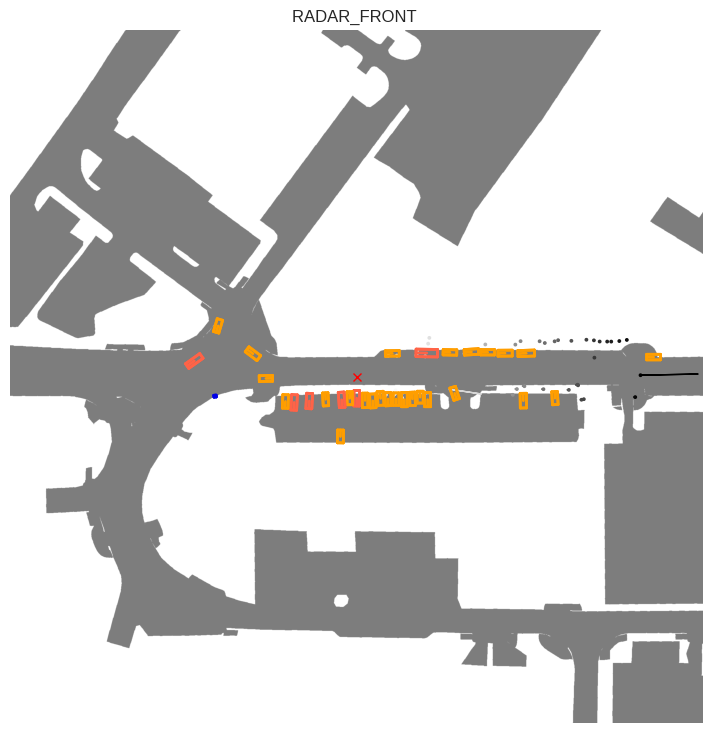

当前sample_token: 5f3fc3c1d08b47cabc1bbca600abbfa8,已前进到时间步: 23


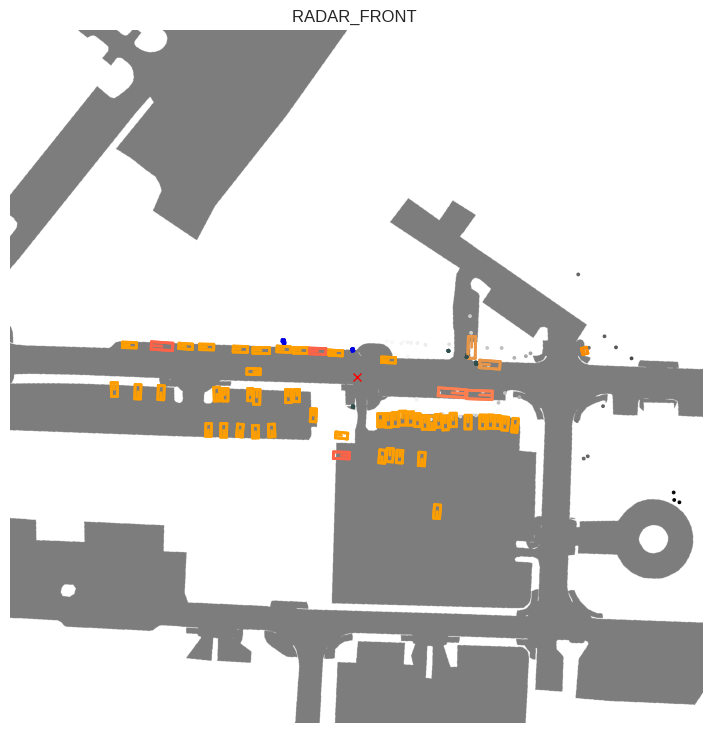

In [39]:
sample_idx =22
scene_id = batch["scene_ids"][sample_idx]
print(f"trajdata场景ID: {scene_id}")

scene_ts = batch["scene_ts"][sample_idx].item() 
print(f"场景时间步: {scene_ts}")

scene_dict = {scene['name']: scene for scene in nusc.scene}
scene_match = scene_dict.get(scene_id)

sample_token = scene_match['first_sample_token']
sample = nusc.get('sample', sample_token)
print(f"初始sample_token: {sample_token}")

radar_token = sample['data']['RADAR_FRONT'] 
nusc.render_sample_data(
    sample_data_token=radar_token,
    with_anns=True,  # 显示标注
    underlay_map=True,  # 在下面显示地图
    nsweeps=1,  # 雷达扫描次数
    axes_limit=120,
)
# nusc.render_sample(sample['token'])
current_ts = 0
while current_ts < scene_ts and sample['next'] != '':
    sample_token = sample['next']
    sample = nusc.get('sample', sample_token)
    current_ts += 1

print(f"当前sample_token: {sample_token},已前进到时间步: {current_ts}")
radar_token = sample['data']['RADAR_FRONT'] 
nusc.render_sample_data(
    sample_data_token=radar_token,
    with_anns=True,  # 显示标注
    underlay_map=True,  # 在下面显示地图
    nsweeps=1,  # 雷达扫描次数
    axes_limit=120,
)
# nusc.render_sample(sample['token'])

video_path = f'{scene_id}.avi'
nusc.render_scene_channel(scene_match['token'], 'CAM_FRONT', out_path=video_path)


 torch.Size([32, 46, 3, 3])


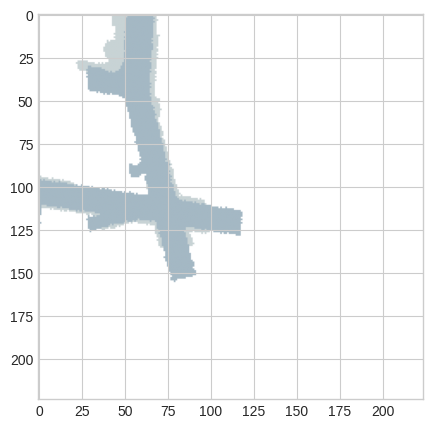

In [143]:
batch_idx =0
agent_idx = 0
map = batch['maps'][batch_idx,agent_idx].permute(1, 2, 0).cpu().numpy()
custom_map = np.ones((map.shape[0], map.shape[1], 3))
custom_map[map[:,:,2] > 0] = np.array([200, 211, 213]) / 255.
custom_map[map[:,:,1] > 0] = np.array([164, 184, 196]) / 255.
custom_map[map[:,:,0] > 0] = np.array([164, 184, 196]) / 255.
fig, ax = plt.subplots(figsize=(5,5))
ax.imshow(custom_map)

hist = batch['agent_hist'][batch_idx,:,:,:2] #([46, 21, 2])
fut = batch['agent_fut'][batch_idx,:,:,:2] #([46, 70, 2])
raster_from_world = batch['raster_from_world']#(3,3)
raster_from_agent = batch['raster_from_agent']#(3,3)
centered_world_from_agent_tf = batch['centered_world_from_agent_tf']#(B,3,3)

print(f" {batch['raster_from_world'].shape}")


# centered_world_from_agent_tf.shape

tensor(40)

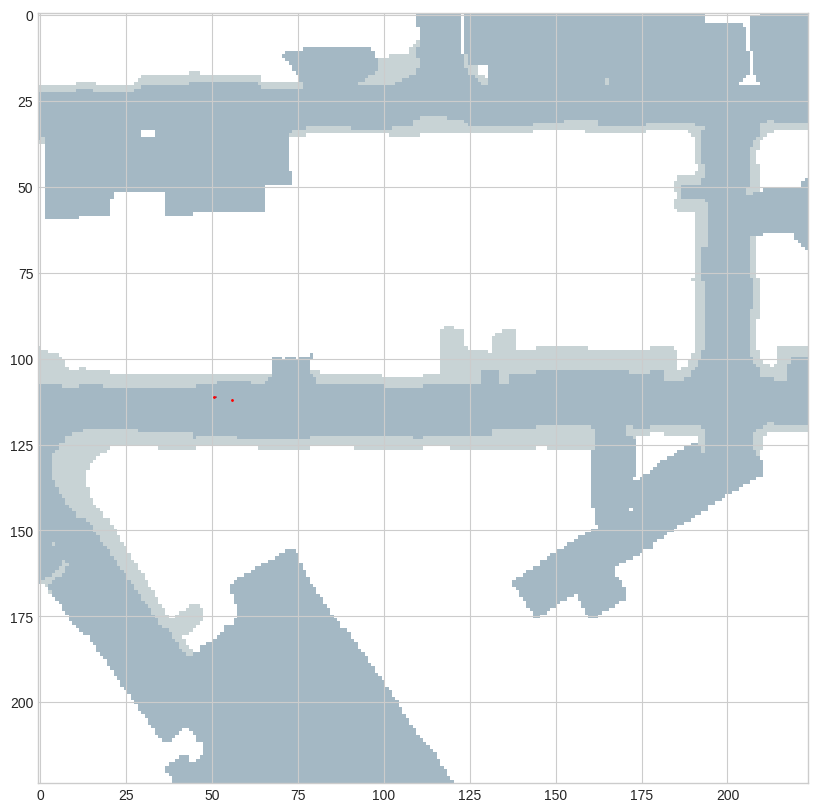

In [43]:
ego_agent_idx =0 # 或1，取决于您的数据集设置
ego_map = batch['maps'][sample_idx, ego_agent_idx].permute(1, 2, 0).cpu().numpy()
custom_map = np.ones((ego_map.shape[0], ego_map.shape[1], 3))
custom_map[ego_map[:,:,2] > 0] = np.array([200, 211, 213]) / 255.
custom_map[ego_map[:,:,1] > 0] = np.array([164, 184, 196]) / 255.
custom_map[ego_map[:,:,0] > 0] = np.array([164, 184, 196]) / 255.
fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(custom_map)

agent_hist = batch['agent_hist'][0,...,:2].cpu().numpy()  # 获取代理历史数据(47,21,8)
raster_from_world = batch['raster_from_agent'].cpu().numpy()
history_raster = transform_points(agent_hist, raster_from_world)

agent_future = batch['agent_fut'][0,...,:2].cpu().numpy()
future_raster = transform_points(agent_future, raster_from_world)

# 使用不同的颜色绘制历史和未来轨迹
history_colors = plt.cm.rainbow(np.linspace(1, 2, history_raster.shape[0]))
future_colors = plt.cm.viridis(np.linspace(0, 1, future_raster.shape[0]))

num_agents = batch['num_agents'][sample_idx]
for agent_idx in range(2):
    # 绘制历史轨迹
    agent_trajectory_hist = history_raster[agent_idx]
    plt.plot(
        agent_trajectory_hist[:, 0], 
        agent_trajectory_hist[:, 1], 
        '-', 
        color=history_colors[agent_idx],
        linewidth=1,
        alpha=0.7
    )
    # 在历史轨迹起点绘制点
    plt.plot(
        agent_trajectory_hist[0, 0],
        agent_trajectory_hist[0, 1],
        'o',
        color=history_colors[agent_idx],
        markersize=1
    )
    # 绘制未来轨迹
    agent_trajectory_fut = future_raster[agent_idx]
    plt.plot(
        agent_trajectory_fut[:, 0], 
        agent_trajectory_fut[:, 1], 
        '-',  # 使用虚线表示未来轨迹
        color=future_colors[agent_idx],
        linewidth=1,
        alpha=0.5
    )
 
num_agents
